# Parliamentary Inquiry Text Mining Report

**Author:** Juan Vargas T.  
**Email:** juan.vargastorres@student.uts.edu.au  
**Website:** [https://jsebastianv.com](https://jsebastianv.com)

---


## Table of Contents

Use the links below to jump to each section.

0. [Utilities](#utilities)
   - [0.0 Environment setup](#utilities)
   - [0.1 Imports and package setup](#utilities)
   - [0.2 Global constants and visual theme](#utilities)
   - [0.3 Data models and metadata parsing classes](#utilities)
   - [0.4 Corpus ingestion service class](#utilities)
   - [0.5 Text preprocessing class and helper functions](#utilities)
1. [Introduction](#introduction)
2. [Data Ingestion](#data-ingestion)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
   - [3.1 Corpus overview visuals](#exploratory-data-analysis)
   - [3.2 Corpus composition by submitter type](#exploratory-data-analysis)
   - [3.3 Distribution of document word counts](#exploratory-data-analysis)
   - [3.4 Relationship between pages and word counts](#exploratory-data-analysis)
   - [3.5 Character counts by submitter type](#exploratory-data-analysis)
   - [3.6 Part-of-Speech (POS) analysis](#exploratory-data-analysis)
   - [3.7 Prepare cleaned tokens and lexical metrics](#exploratory-data-analysis)
   - [3.8 Most common words (clean tokens)](#exploratory-data-analysis)
   - [3.9 Corpus snapshot statistics](#exploratory-data-analysis)
   - [3.10 Length comparison by submitter type](#exploratory-data-analysis)
   - [3.11 Frequency table preparation (unigrams, bigrams, and trigrams)](#exploratory-data-analysis)
   - [3.12 Top unigram frequency chart](#exploratory-data-analysis)
   - [3.13 Top bigram frequency chart](#exploratory-data-analysis)
   - [3.14 Top three-gram frequency chart](#exploratory-data-analysis)
   - [3.15 Initial EDA Interpretation](#exploratory-data-analysis)
4. [Basic Analysis](#basic-analysis)
   - [4.0 Interpretation guidance](#basic-analysis)
   - [4.1 Pre-processing](#pre-processing)
   - [4.1.1 Preprocessing pipeline (normalization + stemming)](#pre-processing)
   - [4.2 Word Frequencies and Collocations](#word-frequencies)
   - [4.2.1 Method focus](#word-frequencies)
   - [4.2.2 Frequency distribution on preprocessed text](#word-frequencies)
   - [4.2.3 Collocation analysis (PMI)](#word-frequencies)
   - [4.2.4 Word cloud of preprocessed corpus](#word-frequencies)
5. [Advanced Methods (Topic Modeling / RegEx)](#topic-modeling)
   - [5.1 Topic modeling with LDA](#topic-modeling)
   - [5.2 Topic prevalence across submissions](#topic-modeling)
   - [5.3 RegEx pattern mining](#topic-modeling)
   - [5.4 Named Entity Recognition on submission text](#topic-modeling)
   - [5.5 Named Entity Recognition on submitter names (filename metadata)](#topic-modeling)
   - [5.6 Method comparison](#topic-modeling)
6. [Conclusion](#conclusion)
7. [References](#references)

---

<a id="utilities"></a>

## 0. Utilities

This section centralizes reusable setup so the rest of the notebook is clean and modular.

Utilities sub-sections are listed in the Table of Contents above.

### 0.0 Environment setup

Run this once per environment to install all required libraries from the project requirements file.

In [194]:
# 0.0 Install required libraries
%pip install -r requirements.txt

import sys
import subprocess

if sys.version_info < (3, 14):
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
else:
    print("spaCy model download skipped on Python 3.14+; NLTK fallback will be used for NER.")

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.0 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### 0.1 Imports and package setup

Load required Python libraries and NLTK resources used throughout the notebook.

In [195]:
# 0.1 Imports and package setup

from pathlib import Path
import re
import string
import logging
import sys
import subprocess
from dataclasses import dataclass
from collections import Counter
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

try:
    from pypdf import PdfReader
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pypdf"])
    from pypdf import PdfReader

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import PorterStemmer
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk import pos_tag, ne_chunk

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

logging.getLogger("pypdf").setLevel(logging.ERROR)
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("nlp_report")


### 0.2 Global constants and visual theme

Define palette values, stopword settings, label mappings, and plotting defaults.

In [ ]:
# 0.2 Global constants and visual theme

UTS_PALETTE = {
    "blue": "#0F4BEB",
    "red": "#FF2305",
    "black": "#000000",
    "dark_grey": "#323232",
    "mid_grey": "#B2B2B2",
    "light_grey": "#EBEBEB",
    "white": "#FFFFFF",
}

DOCS_DIR = Path("docs")
# DOMAIN_STOPWORDS contains words that are contextually frequent but not meaningful for semantic analysis
# in the parliamentary submissions corpus. These include words describing the process or context
# ("submission", "submissions", "inquiry", "committee", "electoral", "election", "federal", 
# "australian", "australia", "parliament") that do not add value for content-based text mining.
DOMAIN_STOPWORDS = {
    "submission", "submissions", "inquiry", "committee", "electoral",
    "election", "federal", "australian", "australia", "parliament"
}

# PUNCT_SET includes standard punctuation plus additional typographical marks and quotation variants
# that may occur in parliamentary submissions. This is to robustly detect and remove all forms of
# punctuation, including ellipses and different quote and dash styles, for thorough token cleaning.
PUNCT_SET = set(string.punctuation).union({
    "...", "''", "``", "’", "“", "”", "–", "—", ".", ","
})

SPACY_ENTITY_LABEL_DESCRIPTIONS = {
    "PERSON": "People, including fictional",
    "NORP": "Nationalities, Religious, or Political groups",
    "FAC": "Buildings, Airports, Highways, Bridges, etc.",
    "ORG": "Companies, Agencies, Institutions, etc.",
    "GPE": "Countries, Cities, States",
    "LOC": "Non-GPE locations, Mountain ranges, Bodies of water",
    "PRODUCT": "Objects, Vehicles, Foods, etc. (Not services)",
    "EVENT": "Named hurricanes, battles, wars, sports events, etc.",
    "WORK_OF_ART": "Titles of books, songs, etc.",
    "LAW": "Named documents made into laws",
    "LANGUAGE": "Any named language",
    "DATE": "Absolute or relative dates or periods",
    "TIME": "Times smaller than a day",
    "PERCENT": "Percentage",
    "MONEY": "Monetary values, including unit",
    "QUANTITY": "Measurements, as of weight or distance",
    "ORDINAL": "First, second, etc.",
    "CARDINAL": "Numerals that do not fall under another type",
}

ORG_NAME_INDICATORS = {
    "association", "assn", "institute", "foundation", "committee", "commission",
    "council", "union", "party", "group", "alliance", "network", "society",
    "organisation", "organization", "org", "company", "co", "corp", "corporation",
    "inc", "inc.", "ltd", "ltd.", "limited", "pty", "pty.", "trust", "church",
    "club", "board", "authority", "agency", "department", "office", "branch",
}
ORG_OVERRIDE_LABELS = {"NORP", "CARDINAL", "GPE"}

PENN_POS_TAG_MAP = {
    "CC": "Coordinating conjunction",
    "CD": "Cardinal number",
    "DT": "Determiner",
    "EX": "Existential there",
    "FW": "Foreign word",
    "IN": "Preposition/subordinating conjunction",
    "JJ": "Adjective",
    "JJR": "Adjective, comparative",
    "JJS": "Adjective, superlative",
    "LS": "List item marker",
    "MD": "Modal",
    "NN": "Noun, singular/common",
    "NNS": "Noun, plural",
    "NNP": "Proper noun, singular",
    "NNPS": "Proper noun, plural",
    "PDT": "Predeterminer",
    "POS": "Possessive ending",
    "PRP": "Personal pronoun",
    "PRP$": "Possessive pronoun",
    "RB": "Adverb",
    "RBR": "Adverb, comparative",
    "RBS": "Adverb, superlative",
    "RP": "Particle",
    "TO": "to",
    "UH": "Interjection",
    "VB": "Verb, base form",
    "VBD": "Verb, past tense",
    "VBG": "Verb, gerund/present participle",
    "VBN": "Verb, past participle",
    "VBP": "Verb, non-3rd person singular present",
    "VBZ": "Verb, 3rd person singular present",
    "WDT": "Wh-determiner",
    "WP": "Wh-pronoun",
    "WP$": "Possessive wh-pronoun",
    "WRB": "Wh-adverb",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.edgecolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["axes.labelcolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["text.color"] = UTS_PALETTE["dark_grey"]

NLP = None
try:
    import spacy
    NLP = spacy.load("en_core_web_sm")
    LOGGER.info("Spacy model successfuly loaded")

except Exception:
    LOGGER.warning("spaCy is unavailable in this Python environment; NLTK fallback will be used for NER.")

2026-03-08 23:09:07,761 | INFO | Spacy model successfuly loaded


### 0.3 Data models and metadata parsing classes

Define configuration/data classes and metadata parsing logic.

In [197]:
# 0.3 Data models and metadata parsing classes

@dataclass(frozen=True)
class CorpusConfig:
    """Configuration object for ingestion and basic corpus filtering."""
    docs_dir: Path
    min_word_count: int = 1


class MetadataParser:
    """Parses metadata and provides metadata-linked NER utilities."""

    @staticmethod
    def infer_submitter_type(name: str, nlp_model=None) -> str:
        """Infer submitter category from submitter name using spaCy NER labels."""
        lowered = name.lower()
        if "withheld" in lowered or "name withheld" in lowered or "withhold" in lowered:
            return "Withheld"

        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return "Unknown"

        doc = model(name)
        labels = [ent.label_ for ent in doc.ents if ent.label_]
        unique_labels = list(dict.fromkeys(labels))
        filtered_labels = [label for label in unique_labels if label != "DATE"]
        LOGGER.info(
            "spaCy NER labels for '%s': all=%s | filtered=%s",
            name,
            set(unique_labels),
            set(filtered_labels),
        )

        if not filtered_labels:
            # Fallback heuristic: infer organisation when common org tokens appear.
            if any(indicator in lowered for indicator in ORG_NAME_INDICATORS):
                return SPACY_ENTITY_LABEL_DESCRIPTIONS["ORG"]
            return "Unknown"

        # Keep a single label with priority: ORG > PERSON > first remaining.
        if "ORG" in filtered_labels:
            selected_label = "ORG"
        elif "PERSON" in filtered_labels:
            selected_label = "PERSON"
        else:
            selected_label = filtered_labels[0]

        if selected_label in ORG_OVERRIDE_LABELS:
            selected_label = "ORG"

        return SPACY_ENTITY_LABEL_DESCRIPTIONS.get(selected_label, selected_label)

    @staticmethod
    def parse_filename(file_name: str) -> tuple[str, str, str]:
        """Parse file name into submission id, submitter name, and submitter type."""
        base = file_name.replace(".pdf", "")
        id_match = re.match(r"^(SupSub\d+\.\d+|Sub\d+(?:\sAtt\d+)?)", base)
        submission_id = id_match.group(1) if id_match else "Unknown"

        parts = base.split(" - ", 1)
        submitter = parts[1].strip() if len(parts) > 1 else "Unknown"
        submitter_type = MetadataParser.infer_submitter_type(submitter)
        return submission_id, submitter, submitter_type

    @staticmethod
    def extract_named_entities(text_series: pd.Series, nlp_model=None, max_docs: int | None = 120) -> pd.DataFrame:
        """Extract named entities using spaCy when available, else fallback to NLTK chunking."""
        records = []
        iterable = text_series.head(max_docs) if max_docs is not None else text_series

        if nlp_model is not None:
            LOGGER.info("NER extraction started with spaCy (max_docs=%s)", max_docs)
            for doc_id, text in enumerate(iterable):
                doc = nlp_model(str(text))
                for ent in doc.ents:
                    if ent.text.strip():
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": ent.text.strip(),
                                "label": ent.label_,
                            }
                        )
            LOGGER.info("NER extraction finished with spaCy: %d entities", len(records))
            return pd.DataFrame(records)

        LOGGER.info("spaCy unavailable; using NLTK fallback for NER (max_docs=%s)", max_docs)
        # NLTK fallback for environments where spaCy is unavailable
        for doc_id, text in enumerate(iterable):
            tokens = word_tokenize(str(text))
            if not tokens:
                continue

            tagged = pos_tag(tokens)
            chunks = ne_chunk(tagged, binary=False)

            for chunk in chunks:
                if hasattr(chunk, "label"):
                    entity_text = " ".join(token for token, _ in chunk.leaves()).strip()
                    if entity_text:
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": entity_text,
                                "label": chunk.label(),
                            }
                        )

        return pd.DataFrame(records)

### 0.4 Corpus ingestion service class

Define the service that reads PDFs and builds ingestion records.

In [198]:
# 0.4 Corpus ingestion service class

class CorpusIngestionService:
    """Single-responsibility service for PDF extraction and corpus construction."""

    def __init__(self, config: CorpusConfig):
        """Initialize service with runtime corpus configuration."""
        self.config = config

    def extract_pdf_text(self, pdf_path: Path) -> tuple[str, int, bool]:
        """Extract text from a PDF and return text, page count, and extraction status."""
        text_parts = []
        page_count = 0
        extraction_ok = True

        try:
            reader = PdfReader(str(pdf_path))
            page_count = len(reader.pages)
            for page in reader.pages:
                text_parts.append(page.extract_text() or "")
        except Exception as exc:
            extraction_ok = False
            LOGGER.warning("Failed to extract PDF: %s | error=%s", pdf_path.name, exc)

        raw_text = "\n".join(text_parts).strip()
        return raw_text, page_count, extraction_ok

    def read_corpus(self) -> pd.DataFrame:
        """Read all submission PDFs and build a filtered corpus dataframe."""
        pdf_paths = sorted(self.config.docs_dir.glob("*.pdf"))
        if not pdf_paths:
            raise FileNotFoundError("No PDFs found in docs/. Confirm dataset path before continuing.")

        LOGGER.info("Starting corpus ingestion from %s (%d files)", self.config.docs_dir, len(pdf_paths))

        records = []
        for pdf_path in pdf_paths:
            submission_id, submitter, submitter_type = MetadataParser.parse_filename(pdf_path.name)
            raw_text, page_count, extraction_ok = self.extract_pdf_text(pdf_path)

            records.append(
                {
                    "file_name": pdf_path.name,
                    "submission_id": submission_id,
                    "submitter": submitter,
                    "submitter_type": submitter_type,
                    "n_pages": page_count,
                    "extraction_ok": extraction_ok,
                    "raw_text": raw_text,
                }
            )

        corpus_df = pd.DataFrame(records)
        corpus_df["raw_text"] = corpus_df["raw_text"].fillna("")
        corpus_df["char_count"] = corpus_df["raw_text"].str.len()
        corpus_df["word_count_raw"] = corpus_df["raw_text"].str.split().str.len()

        filtered_df = corpus_df[corpus_df["word_count_raw"] >= self.config.min_word_count].reset_index(drop=True)
        LOGGER.info("Corpus ingestion complete: %d usable documents", len(filtered_df))
        return filtered_df

### 0.5 Text preprocessing class and helper functions

Define preprocessing utilities, chart helpers, and reusable analysis functions.

In [199]:
# 0.5 Text preprocessing class and helper functions

class TextPreprocessor:
    """Encapsulates token cleaning and stemming rules for consistent reuse."""

    def __init__(self, domain_stopwords: set[str], punct_set: set[str]):
        """Build stopword, punctuation filters, and stemmer resources."""
        base_stopwords = set(stopwords.words("english"))
        self.stop_words = base_stopwords.union(domain_stopwords)
        self.punct_set = punct_set
        self.stemmer = PorterStemmer()

    def clean_tokens(self, text: str) -> list[str]:
        """Convert raw text into normalized, filtered alphabetic tokens."""
        tokens = word_tokenize(text.lower())
        return [
            token for token in tokens
            if token not in self.stop_words
            and token not in self.punct_set
            and token.isalpha()
            and len(token) > 2
        ]

    def preprocess_with_stemming(self, text: str) -> str:
        """Apply normalization, filtering, and stemming; return cleaned text string."""
        cleaned_tokens = self.clean_tokens(text)
        stemmed_tokens = [self.stemmer.stem(token) for token in cleaned_tokens]
        return " ".join(stemmed_tokens)


class Visuals:
    """Reusable plotting helper for consistent chart styling and labeling."""

    def __init__(self, palette: dict[str, str]):
        """Initialize chart helper with a shared color palette."""
        self.palette = palette

    def bar(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str, color: str | None = None,
            hue: str | None = None, palette=None, figsize: tuple[int, int] = (10, 6), ax=None,
            gradient_by_value: bool = True, alpha_min: float = 0.25, alpha_max: float = 0.95):
        """Draw a configurable vertical bar chart with optional value-based opacity gradient."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.barplot(data=data, x=x, y=y, color=color, hue=hue, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Apply a gradient where higher values are rendered with higher opacity.
        if gradient_by_value and ax.patches:
            bar_values = [max(patch.get_width(), patch.get_height()) for patch in ax.patches]
            min_val = min(bar_values)
            max_val = max(bar_values)

            for patch, value in zip(ax.patches, bar_values):
                if max_val == min_val:
                    alpha = (alpha_min + alpha_max) / 2
                else:
                    scale = (value - min_val) / (max_val - min_val)
                    alpha = alpha_min + (scale * (alpha_max - alpha_min))
                patch.set_alpha(alpha)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def hist(self, series: pd.Series, title: str, xlabel: str, ylabel: str, bins: int = 30,
             color: str | None = None, edgecolor: str | None = None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable histogram from a series."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.histplot(series, bins=bins, color=color, edgecolor=edgecolor, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def box(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
            palette=None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable boxplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def scatter(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
                hue: str | None = None, palette=None, alpha: float = 0.7,
                figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable scatterplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def wordcloud(self, text: str, title: str, width: int = 1200, height: int = 500, max_words: int = 150,
                  colormap: str = "Blues", background_color: str | None = None, figsize: tuple[int, int] = (14, 6)):
        """Draw a word cloud from input text with consistent notebook styling."""
        cloud = WordCloud(
            width=width,
            height=height,
            max_words=max_words,
            colormap=colormap,
            collocations=False,
            background_color=background_color or self.palette["white"],
        ).generate(text)

        plt.figure(figsize=figsize)
        plt.imshow(cloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, color=self.palette["dark_grey"])
        plt.tight_layout()
        plt.show()


def compute_ngram_counts(token_sequences: Iterable[list[str]], n: int = 2) -> Counter:
    """Compute n-gram frequencies from tokenized documents."""
    return Counter(gram for tokens in token_sequences for gram in ngrams(tokens, n))


def extract_top_terms_per_topic(model: LatentDirichletAllocation, feature_names: np.ndarray, top_n: int = 10) -> pd.DataFrame:
    """Return a dataframe containing top terms for each topic in an LDA model."""
    topic_rows = []
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:top_n]
        topic_rows.append(
            {
                "topic": f"Topic {topic_idx + 1}",
                "top_terms": ", ".join(feature_names[top_indices]),
            }
        )
    return pd.DataFrame(topic_rows)


def extract_regex_counts(text_series: pd.Series, pattern: str) -> pd.Series:
    """Extract regex matches from text series and return sorted frequency counts."""
    matches = text_series.str.findall(pattern)
    flattened = [item for sublist in matches for item in sublist]
    return pd.Series(flattened).value_counts()



<a id="introduction"></a>

## 1. Introduction

This report analyses public submissions to the Australian parliamentary inquiry into the conduct of the 2025 federal election. Parliamentary inquiries play an important role in democratic policy development by collecting evidence from individuals and organisations and translating that evidence into recommendations for parliament. Using Natural Language Processing (NLP), this project transforms a large PDF-based corpus of submissions into interpretable insights about dominant concerns, recurring themes, and language patterns in public perspectives.

The analysis aims to answer three core questions: (1) What topics and issues appear most frequently across submissions? (2) How do linguistic patterns vary across different submitter types or submission groups inferred from metadata? and (3) What evidence-based insights can be communicated clearly to non-technical audiences? To address these questions, the workflow combines text extraction, preprocessing, exploratory analysis, and method-driven modeling with visual interpretation and plain-language reporting.

<a id="data-ingestion"></a>

## 2. Data Ingestion

### Section Focus

This section loads all PDF submissions from `docs/`, extracts document text, and builds a structured corpus table for downstream NLP analysis.

**What this ingestion step delivers:**
- one row per submission document,
- metadata parsed from filenames (submission ID, submitter label, simple submitter type),
- extraction diagnostics (page count, extraction status),
- text-length features (character and word counts),
- a clean `corpus_df` dataframe used in all later analysis sections.

In [200]:
# 2.0 Data ingestion execution: build corpus dataframe using configured services

config = CorpusConfig(docs_dir=DOCS_DIR, min_word_count=1)
ingestion_service = CorpusIngestionService(config)
preprocessor = TextPreprocessor(domain_stopwords=DOMAIN_STOPWORDS, punct_set=PUNCT_SET)
visuals = Visuals(UTS_PALETTE)

corpus_df = ingestion_service.read_corpus()

LOGGER.info("Documents discovered: %d", len(list(DOCS_DIR.glob('*.pdf'))))
LOGGER.info("Documents with extracted text: %d", len(corpus_df))
LOGGER.info("Submitter type counts:\n%s", corpus_df["submitter_type"].value_counts())

print(f"Documents discovered: {len(list(DOCS_DIR.glob('*.pdf')))}")
print(f"Documents with extracted text: {len(corpus_df)}")
print("\nSubmitter type counts:")
print(corpus_df["submitter_type"].value_counts())

corpus_df.head(5)

2026-03-08 23:09:07,804 | INFO | Starting corpus ingestion from docs (299 files)
2026-03-08 23:09:07,813 | INFO | spaCy NER labels for 'Bob McMullan': all={'PERSON'} | filtered={'PERSON'}
2026-03-08 23:09:07,850 | INFO | spaCy NER labels for 'Dr Sheppard': all={'PERSON'} | filtered={'PERSON'}
2026-03-08 23:09:07,878 | INFO | spaCy NER labels for 'Grattan Institute': all={'ORG'} | filtered={'ORG'}
2026-03-08 23:09:08,361 | INFO | spaCy NER labels for 'Australian Electoral Commission': all={'ORG'} | filtered={'ORG'}
2026-03-08 23:09:09,059 | INFO | spaCy NER labels for 'The Australia Institute': all={'ORG'} | filtered={'ORG'}
2026-03-08 23:09:09,705 | INFO | spaCy NER labels for 'Andrew Murray': all={'PERSON'} | filtered={'PERSON'}
2026-03-08 23:09:09,724 | INFO | spaCy NER labels for 'Genevieve Grant': all={'PERSON'} | filtered={'PERSON'}
2026-03-08 23:09:09,747 | INFO | spaCy NER labels for 'Richard Ure': all={'PERSON'} | filtered={'PERSON'}
2026-03-08 23:09:09,760 | INFO | spaCy NER l

Documents discovered: 299
Documents with extracted text: 299

Submitter type counts:
submitter_type
People, including fictional                132
Withheld                                    99
Companies, Agencies, Institutions, etc.     53
Unknown                                     15
Name: count, dtype: int64


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
0,Sub001 - Bob McMullan.pdf,Sub001,Bob McMullan,"People, including fictional",2,True,Time to revisit territory representation \nInt...,4131,662
1,Sub002 - Dr Sheppard.pdf,Sub002,Dr Sheppard,"People, including fictional",4,True,Inquiry into the 2025 federal election\nSubmis...,4990,782
2,Sub003 - Grattan Institute.pdf,Sub003,Grattan Institute,"Companies, Agencies, Institutions, etc.",13,True,Submission to the Inquiry into the 2025 federa...,35242,4804
3,Sub004 - Australian Electoral Commission.pdf,Sub004,Australian Electoral Commission,"Companies, Agencies, Institutions, etc.",19,True,AEC SUBMISSION \nJoint Standing Committee on E...,68568,10131
4,Sub005 - The Australia Institute.pdf,Sub005,The Australia Institute,"Companies, Agencies, Institutions, etc.",55,True,Australian democracy in \n2025 \nSubmission to...,90092,12137


<a id="exploratory-data-analysis"></a>

## 3. Exploratory Data Analysis

### Section Focus

Following the Week 1 guidance (word counts, frequent terms, and cleaned-token patterns), this section establishes high-level corpus behavior before advanced modeling.

**EDA outputs included below:**
- document-length distribution (histogram + grouped boxplot),
- cleaned-token vocabulary size and lexical diversity,
- top unigrams and bigrams after stopword and punctuation filtering,
- simple submitter-type comparison using filename-derived metadata,
- quick observations to motivate subsequent preprocessing and topic methods.


### 3.1 Corpus overview visuals

This subsection provides a high-level visual overview of the corpus dataframe before detailed token analysis. Charts summarize corpus composition, document scale, and key structural relationships across submissions.

In [201]:
# 3.1 Overview statistics table

overview_stats = corpus_df[["n_pages", "char_count", "word_count_raw"]].describe().T
display(overview_stats)

,count,mean,std,min,25%,50%,75%,max
n_pages,299.0,6.615385,12.334375,1.0,2.0,3.0,6.0,120.0
char_count,299.0,13212.842809,25405.188038,52.0,2084.5,5175.0,11669.5,226824.0
word_count_raw,299.0,2052.381271,4055.464684,8.0,344.5,815.0,1831.5,36278.0


### 3.2 Corpus composition by submitter type

This chart shows how many submissions come from each inferred submitter category.

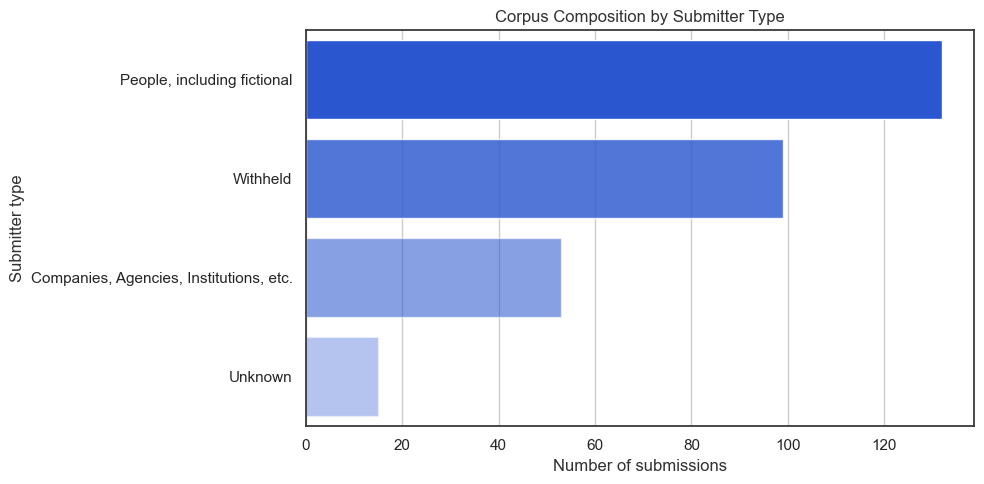

In [202]:
# 3.2 Visual: corpus composition by submitter type

submitter_counts = (
    corpus_df["submitter_type"]
    .value_counts()
    .rename_axis("submitter_type")
    .reset_index(name="count")
)

visuals.bar(
    data=submitter_counts,
    x="count",
    y="submitter_type",
    title="Corpus Composition by Submitter Type",
    xlabel="Number of submissions",
    ylabel="Submitter type",
    color=UTS_PALETTE["blue"],
    gradient_by_value=True,
    alpha_min=0.35,
    alpha_max=1.0,
    figsize=(10, 5),
)

**Analysis.** The corpus is not evenly distributed across submitter types, so later comparisons should be read with both document counts and document lengths in mind. If one category contributes many more submissions than another, simple frequency totals can reflect corpus composition as much as substantive differences in viewpoint.

### 3.3 Distribution of document word counts

This histogram shows the spread of document sizes across submissions.

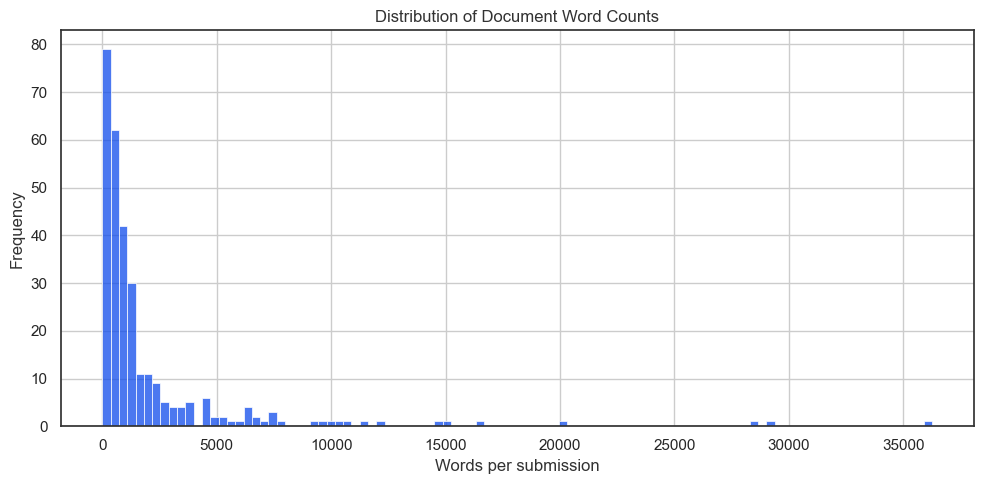

In [203]:
# 3.3 Visual: word-count distribution

visuals.hist(
    series=corpus_df["word_count_raw"],
    bins=100,
    color=UTS_PALETTE["blue"],
    edgecolor=UTS_PALETTE["white"],
    title="Distribution of Document Word Counts",
    xlabel="Words per submission",
    ylabel="Frequency",
    figsize=(10, 5),
)

**Analysis.** Most submissions appear to cluster at the lower end of the distribution, while a long right tail captures a much smaller set of very large documents. This confirms the corpus is highly skewed and helps explain why the median document length is more representative than the mean for describing a typical submission.

In [204]:
# Find and show the entire row for the document with the largest word count
max_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmax()]
print("Document with the largest word count (entire row):")
display(max_word_count_row.to_frame().T)

# Find and show the entire row for the document with the smallest word count
min_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmin()]
print("Document with the smallest word count (entire row):")
display(min_word_count_row.to_frame().T)

Document with the largest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
140,Sub141 Att1 - Malcolm Mackerras.pdf,Sub141 Att1,Malcolm Mackerras,"People, including fictional",96,True,Inquiry into the 2025 federal election\nSubmis...,215643,36278


Document with the smallest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
14,Sub015 - Name withheld.pdf,Sub015,Name withheld,Withheld,1,True,Inquiry into the 2025 federal election\nSubmis...,52,8


### 3.4 Relationship between pages and word counts

This scatter plot compares page counts with total words to show document scale relationships.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_17327/799276666.py:117: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)


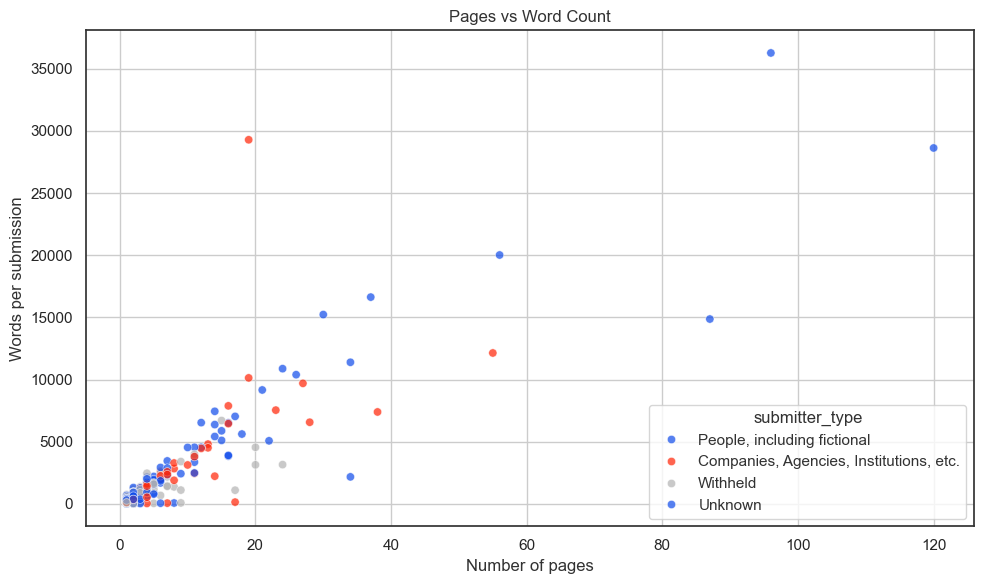

In [205]:
# 3.4 Visual: pages vs word counts

visuals.scatter(
    data=corpus_df,
    x="n_pages",
    y="word_count_raw",
    hue="submitter_type",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    alpha=0.7,
    title="Pages vs Word Count",
    xlabel="Number of pages",
    ylabel="Words per submission",
    figsize=(10, 6),
)

**Analysis.** Word count generally increases with page count, which suggests the extracted text volume broadly matches document length. At the same time, the spread at similar page totals shows that formatting and document style still matter, so page count should be treated as an approximate rather than exact proxy for textual richness.

### 3.5 Character counts by submitter type

This boxplot compares character-count distributions by submitter category.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_17327/799276666.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_17327/799276666.py:98: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)


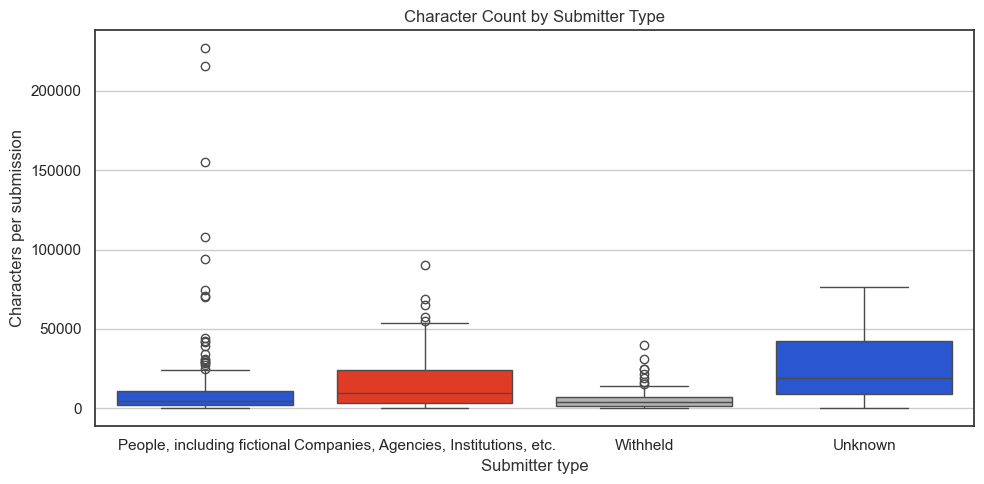

In [206]:
# 3.5 Visual: character count by submitter type

visuals.box(
    data=corpus_df,
    x="submitter_type",
    y="char_count",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    title="Character Count by Submitter Type",
    xlabel="Submitter type",
    ylabel="Characters per submission",
    figsize=(10, 5),
)

**Analysis.** Character counts vary substantially within and across submitter types, showing that some groups contribute much more text than others. This reinforces the need to use robust summary statistics and, where appropriate, normalized text measures so that the largest submissions do not dominate every downstream comparison.

### 3.6 Part-of-Speech (POS) analysis

This cell tags words in submission text using NLTK POS tagging (on a capped sample for runtime) and summarizes the most frequent grammatical categories.

2026-03-08 23:09:50,639 | INFO | POS tagging complete: docs=120, tagged_tokens=207648


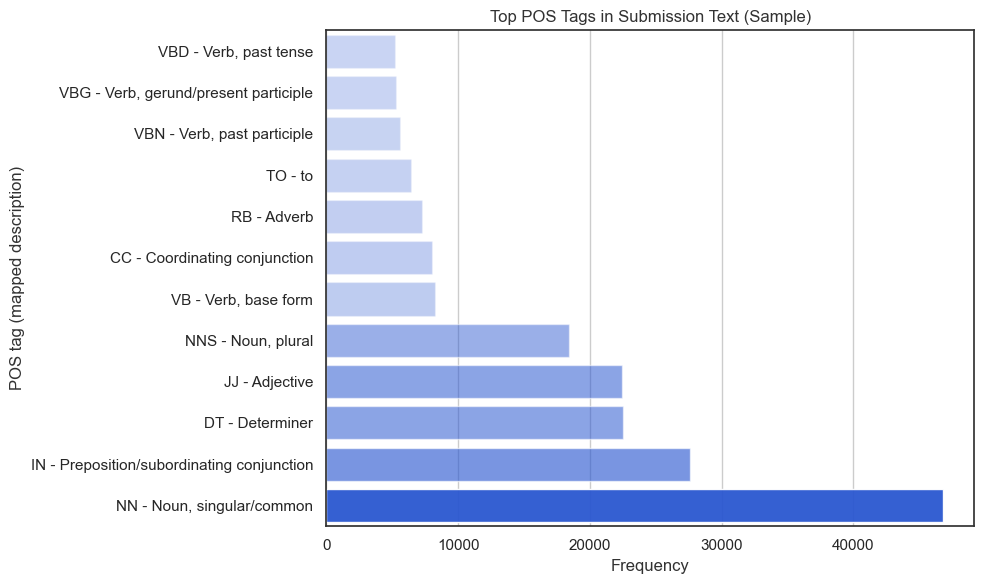

,pos_tag,pos_description,count
11,VBD,"Verb, past tense",5177
10,VBG,"Verb, gerund/present participle",5316
9,VBN,"Verb, past participle",5620
8,TO,to,6399
7,RB,Adverb,7223
6,CC,Coordinating conjunction,8050
5,VB,"Verb, base form",8241
4,NNS,"Noun, plural",18441
3,JJ,Adjective,22461
2,DT,Determiner,22483


In [207]:
# 3.6 POS analysis: top grammatical tags

pos_max_docs = 120
pos_tags = []

for text in corpus_df["raw_text"].head(pos_max_docs):
    tokens = [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
    if not tokens:
        continue
    pos_tags.extend(tag for _, tag in pos_tag(tokens))

pos_tag_counts = pd.Series(pos_tags, name="pos_tag").value_counts().reset_index()
pos_tag_counts.columns = ["pos_tag", "count"]
pos_tag_counts["pos_description"] = pos_tag_counts["pos_tag"].map(PENN_POS_TAG_MAP).fillna("Other/Unknown")
pos_tag_counts["pos_label"] = pos_tag_counts["pos_tag"] + " - " + pos_tag_counts["pos_description"]

top_pos_tags = pos_tag_counts.head(12).sort_values("count", ascending=True)

LOGGER.info(
    "POS tagging complete: docs=%d, tagged_tokens=%d",
    min(pos_max_docs, len(corpus_df)),
    len(pos_tags),
)

visuals.bar(
    data=top_pos_tags,
    x="count",
    y="pos_label",
    color=UTS_PALETTE["blue"],
    title="Top POS Tags in Submission Text (Sample)",
    xlabel="Frequency",
    ylabel="POS tag (mapped description)",
    figsize=(10, 6),
)

top_pos_tags[["pos_tag", "pos_description", "count"]]

**Analysis.** Nouns, prepositions, determiners, and adjectives dominate the POS profile, which is typical of formal submissions that describe institutions, actors, and relationships in detail. This pattern suggests the corpus is rich enough for topical term analysis, although the POS results come from a sample of documents rather than the full collection.

### 3.7 Prepare cleaned tokens and lexical metrics

This cell applies the preprocessing rules, creates cleaned token lists per document, and computes reusable corpus-level metrics such as cleaned word counts and lexical diversity.


In [208]:
# 3.7 Tokenization output and document-level lexical features

corpus_df["clean_tokens"] = corpus_df["raw_text"].apply(preprocessor.clean_tokens)
corpus_df["clean_word_count"] = corpus_df["clean_tokens"].str.len()
corpus_df["lexical_diversity"] = corpus_df.apply(
    lambda r: (len(set(r["clean_tokens"])) / r["clean_word_count"]) if r["clean_word_count"] > 0 else np.nan,
    axis=1,
)

all_tokens = [token for tokens in corpus_df["clean_tokens"] for token in tokens]
vocab_size = len(set(all_tokens))
LOGGER.info("Tokenization complete: vocab_size=%d, docs=%d", vocab_size, len(corpus_df))

corpus_df[["file_name", "word_count_raw", "clean_word_count", "lexical_diversity"]].head(10)


2026-03-08 23:09:52,054 | INFO | Tokenization complete: vocab_size=16666, docs=299


,file_name,word_count_raw,clean_word_count,lexical_diversity
0,Sub001 - Bob McMullan.pdf,662,293,0.453925
1,Sub002 - Dr Sheppard.pdf,782,395,0.713924
2,Sub003 - Grattan Institute.pdf,4804,2340,0.390598
3,Sub004 - Australian Electoral Commission.pdf,10131,5184,0.342207
4,Sub005 - The Australia Institute.pdf,12137,5896,0.292232
5,Sub006 - Andrew Murray.pdf,339,149,0.885906
6,Sub007 - Genevieve Grant.pdf,648,300,0.776667
7,Sub008 - Richard Ure.pdf,606,294,0.697279
8,Sub009 - Barry Searle.pdf,333,158,0.822785
9,Sub010 - Name withheld.pdf,130,50,0.940000


### 3.8 Most common words

This subsection focuses on visualization only. Using the cleaned tokens prepared in the previous step, it shows the most common terms across the full corpus and within each `submitter_type`.


2026-03-08 23:09:52,089 | INFO | Clean token visualization prepared: unique_clean_tokens=16666


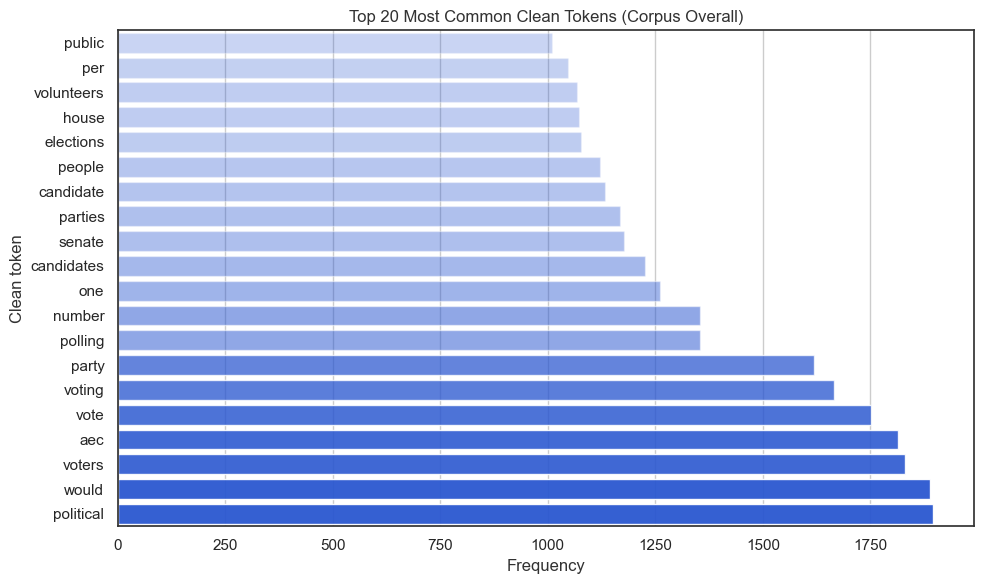

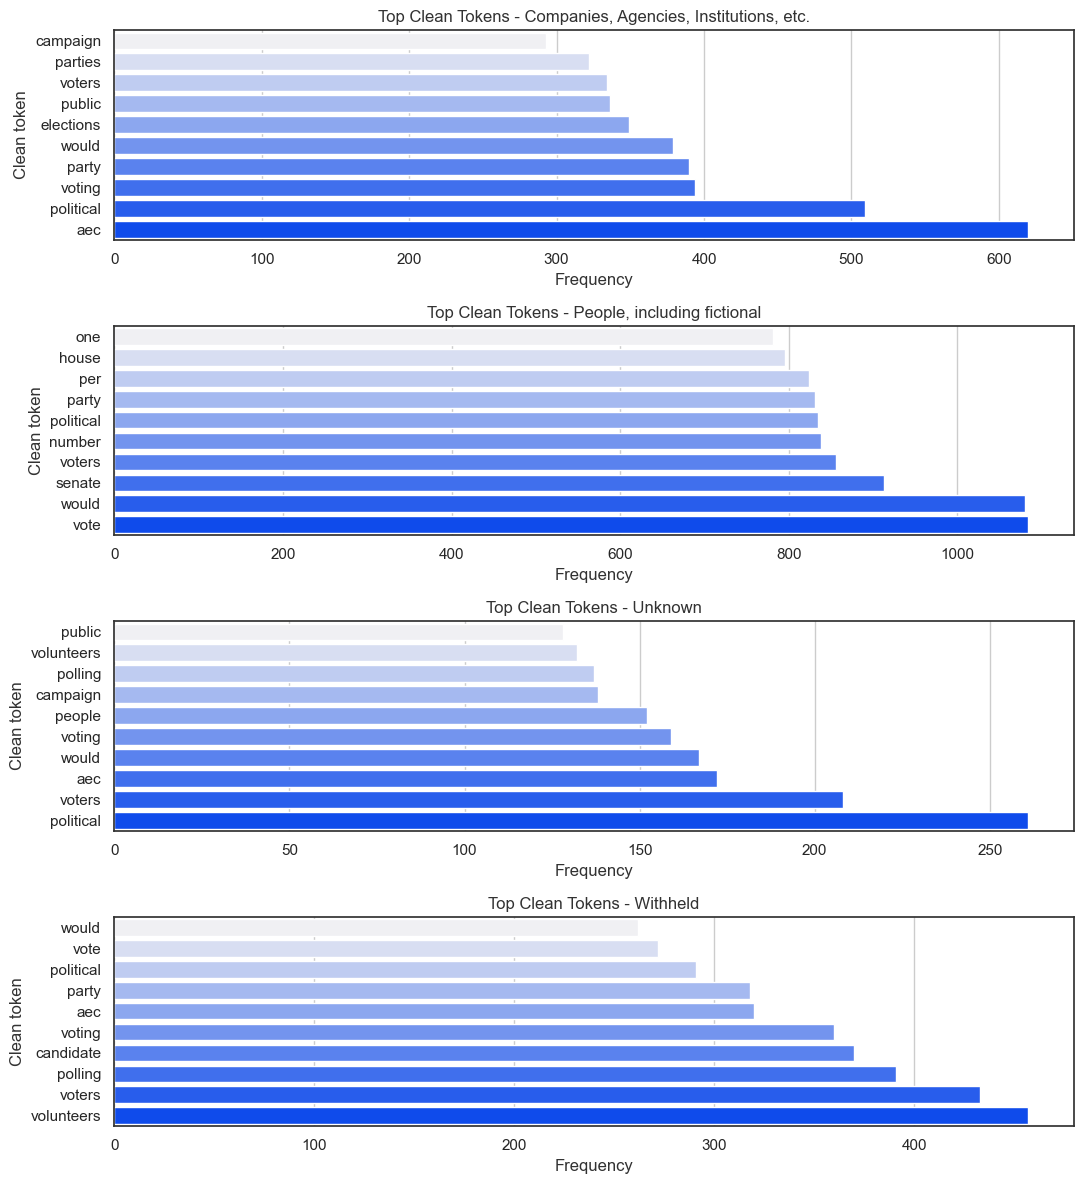

Top clean tokens by submitter type (top 10 each):


,submitter_type,word,count
0,"Companies, Agencies, Institutions, etc.",aec,620
1,"Companies, Agencies, Institutions, etc.",political,509
2,"Companies, Agencies, Institutions, etc.",voting,394
3,"Companies, Agencies, Institutions, etc.",party,390
4,"Companies, Agencies, Institutions, etc.",would,379
5,"Companies, Agencies, Institutions, etc.",elections,349
6,"Companies, Agencies, Institutions, etc.",public,336
7,"Companies, Agencies, Institutions, etc.",voters,334
8,"Companies, Agencies, Institutions, etc.",parties,322
9,"Companies, Agencies, Institutions, etc.",campaign,293


In [209]:
# 3.8 Visuals: most common words (clean tokens)

overall_word_counter = Counter(all_tokens)
top_words_df = pd.DataFrame(overall_word_counter.most_common(20), columns=["word", "count"])
plot_top_words = top_words_df.sort_values("count", ascending=True)

LOGGER.info("Clean token visualization prepared: unique_clean_tokens=%d", len(overall_word_counter))

# Chart 1: overall top clean tokens
visuals.bar(
    data=plot_top_words,
    x="count",
    y="word",
    color=UTS_PALETTE["blue"],
    title="Top 20 Most Common Clean Tokens (Corpus Overall)",
    xlabel="Frequency",
    ylabel="Clean token",
    figsize=(10, 6),
)

# Top clean tokens by submitter type
rows = []
for submitter_type, group_df in corpus_df.groupby("submitter_type"):
    type_tokens = [
        token
        for tokens in group_df["clean_tokens"]
        for token in tokens
    ]
    type_counter = Counter(type_tokens)
    for word, count in type_counter.most_common(10):
        rows.append({"submitter_type": submitter_type, "word": word, "count": count})

top_words_by_type_df = pd.DataFrame(rows)

# Chart 2: top clean tokens by submitter type (faceted)
submitter_types = list(top_words_by_type_df["submitter_type"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(submitter_types),
    ncols=1,
    figsize=(11, max(3 * len(submitter_types), 6)),
    sharex=False,
)

if len(submitter_types) == 1:
    axes = [axes]

for ax, submitter_type in zip(axes, submitter_types):
    type_data = (
        top_words_by_type_df[top_words_by_type_df["submitter_type"] == submitter_type]
        .sort_values("count", ascending=True)
    )

    sns.barplot(data=type_data, x="count", y="word", color=UTS_PALETTE["blue"], ax=ax)

    gradient_colors = sns.light_palette(UTS_PALETTE["blue"], n_colors=len(type_data))
    for bar, color in zip(ax.patches, gradient_colors):
        bar.set_facecolor(color)

    ax.set_title(f"Top Clean Tokens - {submitter_type}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Clean token")

plt.tight_layout()
plt.show()

print("Top clean tokens by submitter type (top 10 each):")
top_words_by_type_df.sort_values(["submitter_type", "count"], ascending=[True, False]).head(60)


**Analysis.** Because these charts use `clean_tokens`, the dominant terms are easier to interpret than raw-token counts and better reflect substantive inquiry themes rather than formatting noise or stopwords. The faceted comparison by `submitter_type` also makes it easier to see whether different groups emphasize the same cleaned vocabulary or whether each group foregrounds distinct concerns.


### 3.9 Corpus snapshot statistics

This cell reports compact EDA summary statistics used to frame the visual analysis.

In [210]:
# 3.9 Snapshot statistics

print("=== EDA Snapshot ===")
print(f"Documents analysed: {len(corpus_df)}")
print(f"Corpus vocabulary size (clean tokens): {vocab_size:,}")
print(f"Median document word count (raw): {corpus_df['word_count_raw'].median():.0f}")
print(f"Median lexical diversity: {corpus_df['lexical_diversity'].median():.3f}")

=== EDA Snapshot ===
Documents analysed: 299
Corpus vocabulary size (clean tokens): 16,666
Median document word count (raw): 815
Median lexical diversity: 0.660


### 3.10 Length comparison by submitter type

This visual compares raw and cleaned document lengths across submitter categories to show whether the same groups remain relatively longer after preprocessing.

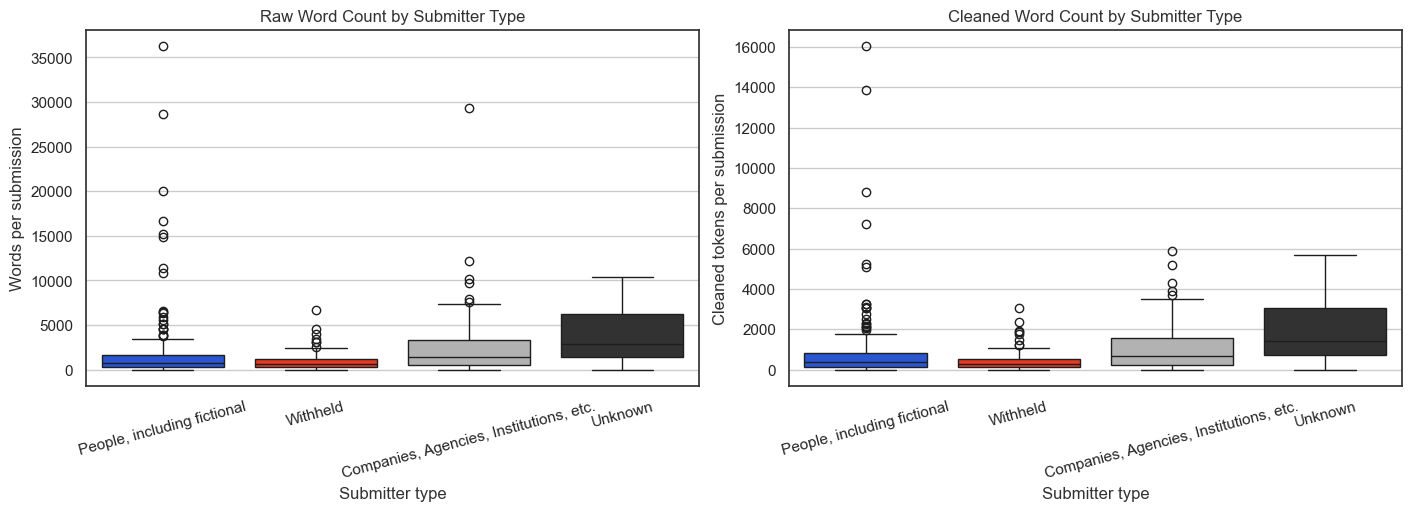

In [211]:
# 3.10 Visual: grouped comparison by submitter type

submitter_order = corpus_df["submitter_type"].dropna().value_counts().index.tolist()
palette_cycle = [
    UTS_PALETTE["blue"],
    UTS_PALETTE["red"],
    UTS_PALETTE["mid_grey"],
    UTS_PALETTE["dark_grey"],
]
submitter_palette = {
    label: palette_cycle[idx % len(palette_cycle)]
    for idx, label in enumerate(submitter_order)
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), constrained_layout=True)

sns.boxplot(
    data=corpus_df,
    x="submitter_type",
    y="word_count_raw",
    order=submitter_order,
    hue="submitter_type",
    palette=submitter_palette,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Raw Word Count by Submitter Type")
axes[0].set_xlabel("Submitter type")
axes[0].set_ylabel("Words per submission")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=corpus_df,
    x="submitter_type",
    y="clean_word_count",
    order=submitter_order,
    hue="submitter_type",
    palette=submitter_palette,
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Cleaned Word Count by Submitter Type")
axes[1].set_xlabel("Submitter type")
axes[1].set_ylabel("Cleaned tokens per submission")
axes[1].tick_params(axis="x", rotation=15)

plt.show()

**Analysis.** Comparing raw and cleaned word counts side by side shows whether preprocessing changes the relative size pattern across submitter types. If the same groups remain longer in both panels, that suggests the difference is structural to the submissions themselves rather than being caused mainly by removable stopwords, punctuation, or formatting noise.

### 3.11 Frequency table preparation (unigrams, bigrams, and trigrams)

This cell computes term and phrase frequencies from cleaned tokens and prepares reusable tables for reporting and charting across one-, two-, and three-word sequences.

In [212]:
# 3.11 Frequency tables

unigram_counts = Counter(all_tokens)
bigram_counts = compute_ngram_counts(corpus_df["clean_tokens"], n=2)
trigram_counts = compute_ngram_counts(corpus_df["clean_tokens"], n=3)

top_unigrams = pd.DataFrame(unigram_counts.most_common(20), columns=["term", "count"])
top_bigrams = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in bigram_counts.most_common(15)],
    columns=["bigram", "count"],
)
top_trigrams = pd.DataFrame(
    [(" ".join(tg), count) for tg, count in trigram_counts.most_common(15)],
    columns=["trigram", "count"],
)

print("Top 10 unigrams:")
display(top_unigrams.head(10))

print("Top 10 bigrams:")
display(top_bigrams.head(10))

print("Top 10 trigrams:")
display(top_trigrams.head(10))

Top 10 unigrams:


,term,count
0,political,1896
1,would,1888
2,voters,1831
3,aec,1815
4,vote,1751
5,voting,1666
6,party,1619
7,polling,1354
8,number,1353
9,one,1261


Top 10 bigrams:


,bigram,count
0,house representatives,513
1,per cent,503
2,political parties,344
3,joint standing,335
4,standing matters,320
5,ballot paper,260
6,political advertising,249
7,polling booth,237
8,polling places,234
9,polling booths,233


Top 10 trigrams:


,trigram,count
0,joint standing matters,317
1,truth political advertising,133
2,new south wales,100
3,ppvc total votes,82
4,state division ppvc,81
5,division ppvc total,81
6,total votes days,81
7,votes days open,81
8,days open avg,81
9,open avg per,81


### 3.12 Top unigram frequency chart

This bar chart visualizes the most common cleaned single-word terms to surface dominant vocabulary in the corpus.

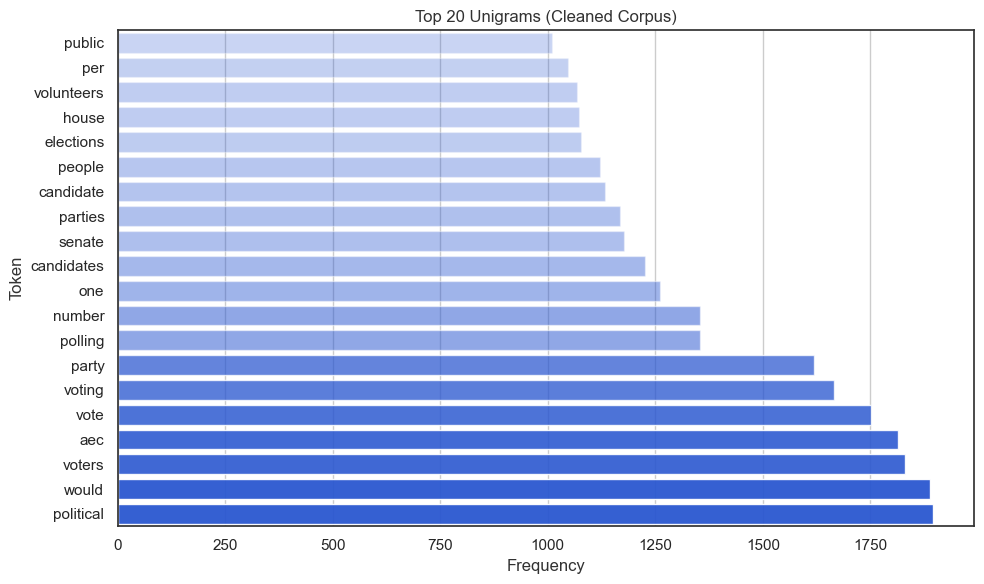

In [213]:
# 3.12 Visual: top unigrams

visuals.bar(
    data=top_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["blue"],
    title="Top 20 Unigrams (Cleaned Corpus)",
    xlabel="Frequency",
    ylabel="Token",
    figsize=(10, 6),
)

**Analysis.** The cleaned unigram chart concentrates on the core language of the inquiry after surface noise has been reduced. Terms such as `election`, `federal`, `submission`, `electoral`, `inquiry`, `political`, `voters`, `aec`, and `vote` indicate that the dataset remains strongly centered on electoral administration, public participation, and institutional process.

### 3.13 Top bigram frequency chart

This bar chart visualizes frequent two-word phrases, which can provide stronger thematic context than unigrams alone.

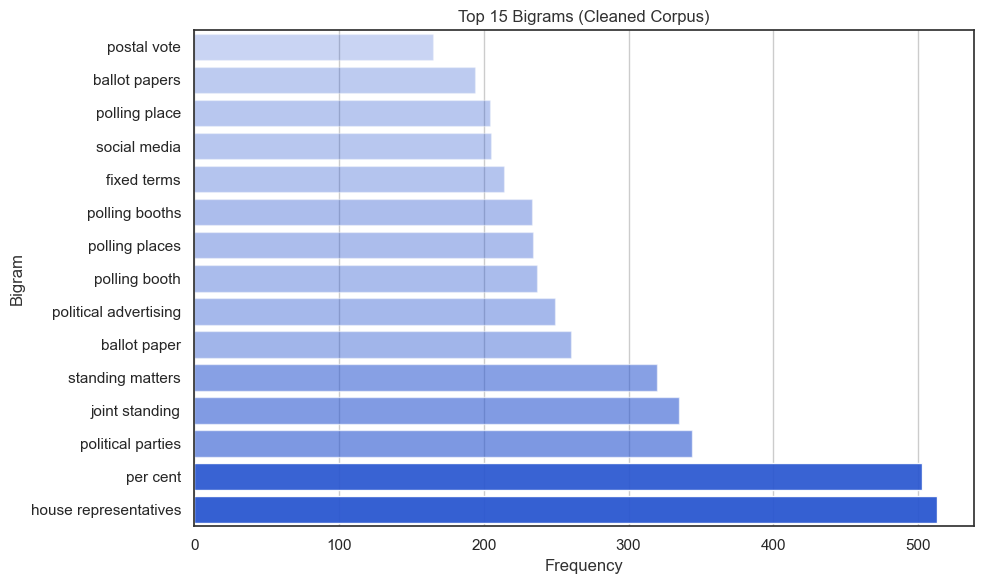

In [214]:
# 3.13 Visual: top bigrams

visuals.bar(
    data=top_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 Bigrams (Cleaned Corpus)",
    xlabel="Frequency",
    ylabel="Bigram",
    figsize=(10, 6),
)

**Analysis.** Bigrams add more context than single terms, so this chart is more revealing than a unigram list when identifying recurring institutional phrases and policy expressions. If the leading bigrams cluster around electoral administration and political process, that suggests participants are repeatedly discussing similar structures and concerns across submissions.

### 3.14 Top three-gram frequency chart

This bar chart visualizes frequent three-word phrases to surface recurring multi-word concepts with more contextual detail than bigrams.

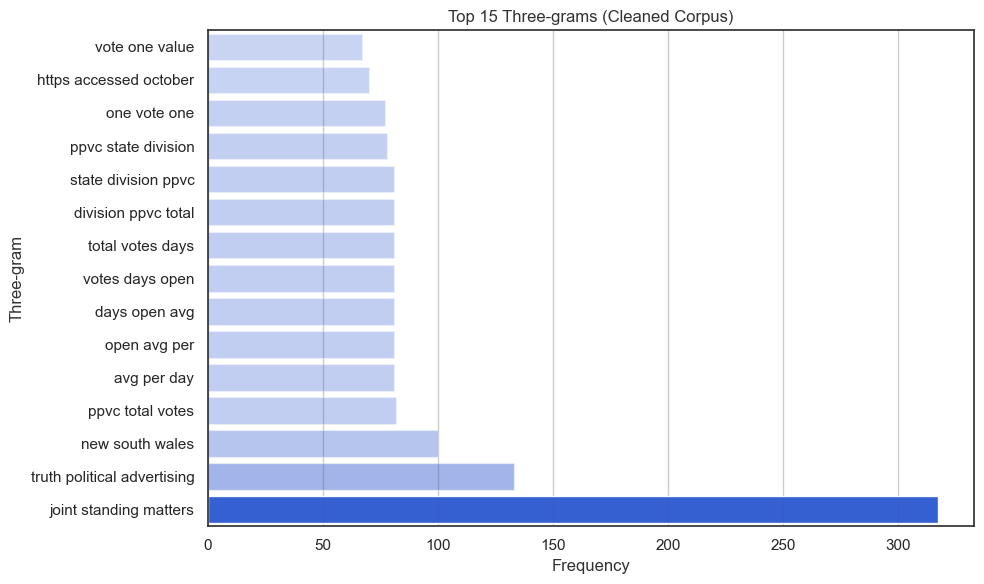

In [215]:
# 3.14 Visual: top three-grams

visuals.bar(
    data=top_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 Three-grams (Cleaned Corpus)",
    xlabel="Frequency",
    ylabel="Three-gram",
    figsize=(10, 6),
)

**Analysis.** Repeated three-word phrases are usually more specific than unigrams or bigrams, so this chart helps surface concrete policy concepts and recurring frames rather than broad topic labels alone. That makes it especially useful for linking frequent language patterns to the more structured themes extracted later with advanced methods.

### 3.15 Initial EDA Interpretation

Using the current extraction run, the corpus contains **299 submissions** with text successfully extracted from all files. Document lengths are highly variable (median around **815 words**), with **organisation submissions generally much longer** than individual and withheld-name submissions.

The cleaned corpus vocabulary is broad (about **16.7k unique tokens**) with median lexical diversity around **0.66**, indicating substantial variation in expression across submissions. High-frequency terms and bigrams such as *political*, *voters*, *AEC*, *house representatives*, and *political advertising* suggest that institutional process, electoral administration, and campaign regulation are dominant early themes.

These EDA findings motivate deeper preprocessing and advanced methods (topic modeling/clustering) in the next sections to separate broad procedural language from distinct issue-specific concerns.

<a id="basic-analysis"></a>

## 4. Basic Analysis

Use sub-sections to structure your methods and findings clearly.

### 4.0 Interpretation Guidance

For each code block, include a short interpretation paragraph that explains:
- what the method does,
- what the output shows,
- why the result matters for your inquiry question,
- and any limitations or caveats.

<a id="pre-processing"></a>

### 4.1 Pre-processing

Document your preprocessing decisions and justify each choice.

**Typical items to report:**
- text normalization,
- tokenization,
- stopword strategy (including domain-specific stopwords),
- stemming/lemmatization,
- handling of punctuation, numbers, and special characters.

### 4.1.1 Preprocessing pipeline (normalization + stemming)

This cell applies a full preprocessing pipeline to each document and stores a stemmed representation. The output helps compare raw text against a standardized form used by later modeling methods.

In [ ]:
# 4.1.1 Apply preprocessing pipeline

corpus_df["preprocessed_text"] = corpus_df["raw_text"].apply(preprocessor.preprocess_with_stemming)
corpus_df["preprocessed_word_count"] = corpus_df["preprocessed_text"].str.split().str.len()

comparison_cols = ["file_name", "word_count_raw", "preprocessed_word_count", "raw_text", "preprocessed_text"]
comparison_view = corpus_df[comparison_cols].head(3).copy()
comparison_view["raw_text"] = comparison_view["raw_text"].str.slice(0, 300) + "..."
comparison_view["preprocessed_text"] = comparison_view["preprocessed_text"].str.slice(0, 300) + "..."

comparison_view

<a id="word-frequencies"></a>

### 4.2 Word Frequencies and Collocations

This subsection extends EDA frequency analysis by using a fully preprocessed representation, collocation scoring, and a visual word cloud to reveal stronger lexical patterns.

Include method description, code, and visual outputs (tables/charts), then interpret:
- which terms dominate,
- whether frequency patterns align with expected inquiry concerns,
- and what these patterns suggest about public priorities.

### 4.2.1 Method focus

The following cells quantify dominant terms, identify statistically meaningful word pairings, and visualize the cleaned corpus vocabulary.

### 4.2.2 Frequency distribution on preprocessed text

This cell calculates unigram frequencies from the stemmed corpus and visualizes the most common terms after full cleanup.

In [ ]:
# 4.2.2 Preprocessed frequency distribution

preprocessed_tokens = [token for text in corpus_df["preprocessed_text"] for token in text.split()]
preprocessed_freq = pd.Series(preprocessed_tokens).value_counts().head(20).reset_index()
preprocessed_freq.columns = ["term", "count"]

visuals.bar(
    data=preprocessed_freq.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["blue"],
    title="Top 20 Terms (After Full Preprocessing)",
    xlabel="Frequency",
    ylabel="Stemmed term",
    figsize=(10, 6),
)

preprocessed_freq.head(10)

**Analysis.** After full preprocessing, the highest-frequency stems foreground substantive themes while reducing the influence of punctuation, inflection, and common filler words. Terms that remain dominant here are therefore stronger indicators of the inquiry's central concerns, although stemming can merge different surface forms into the same root.

### 4.2.3 Collocation analysis (PMI)

This cell identifies word pairs that occur together more strongly than expected by chance using PMI-based collocation scoring.

In [ ]:
# 4.2.3 PMI-based collocations

finder = BigramCollocationFinder.from_words(preprocessed_tokens)
finder.apply_freq_filter(10)
collocation_scores = finder.score_ngrams(BigramAssocMeasures().pmi)

top_collocations = pd.DataFrame(
    [(" ".join(bigram), score) for bigram, score in collocation_scores[:15]],
    columns=["bigram", "pmi_score"],
)

visuals.bar(
    data=top_collocations.sort_values("pmi_score", ascending=True),
    x="pmi_score",
    y="bigram",
    color=UTS_PALETTE["red"],
    title="Top 15 Collocations by PMI",
    xlabel="PMI score",
    ylabel="Bigram",
    figsize=(10, 6),
)

top_collocations

**Analysis.** High-PMI collocations are useful because they emphasize unusually strong word pairings rather than simply the most frequent individual terms. That makes this chart better for surfacing distinctive issue expressions, but PMI can also elevate less common phrases, so statistical salience should still be checked against raw frequency.

### 4.2.4 Word cloud of preprocessed corpus

This visual summary highlights the relative prominence of terms in the fully preprocessed corpus.

In [ ]:
# 4.2.4 Word cloud

visuals.wordcloud(
    text=" ".join(preprocessed_tokens),
    title="Word Cloud of Preprocessed Terms",
    width=1200,
    height=500,
    max_words=150,
    colormap="Blues",
    background_color=UTS_PALETTE["white"],
    figsize=(14, 6),
)

**Analysis.** Unlike the ranked bar charts, the word cloud gives a fast holistic sense of vocabulary prominence and thematic concentration across the preprocessed corpus. It is useful for communication and pattern spotting, but precise comparisons should still rely on the frequency tables and bar charts because the size differences in a word cloud are only approximate.

<a id="topic-modeling"></a>

## 5. Advanced Methods (Topic Modeling / RegEx)

This section introduces model-based thematic extraction and pattern mining methods to move from descriptive frequencies toward structured insights.

### 5.1 Topic modeling with LDA

This cell builds an LDA model from the preprocessed corpus to identify latent themes and summarize each topic using high-probability terms.

In [ ]:
# 5.1 LDA topic modeling

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
dtm = vectorizer.fit_transform(corpus_df["preprocessed_text"])
feature_names = vectorizer.get_feature_names_out()

n_topics = 6
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    max_iter=20,
)
topic_distributions = lda_model.fit_transform(dtm)

topic_terms_df = extract_top_terms_per_topic(lda_model, feature_names, top_n=10)
LOGGER.info("LDA fitted: topics=%d, vocabulary=%d", n_topics, len(feature_names))
topic_terms_df

### 5.2 Topic prevalence across submissions

This cell assigns each submission to its dominant topic and visualizes topic prevalence to show which themes are most represented in the corpus.

In [ ]:
# 5.2 Topic prevalence

corpus_df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1
topic_counts = (
    corpus_df["dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="count")
)

topic_counts["topic"] = topic_counts["topic"].astype(str).radd("Topic ")
LOGGER.info("Topic prevalence computed for %d submissions", len(corpus_df))

visuals.bar(
    data=topic_counts,
    x="topic",
    y="count",
    color=UTS_PALETTE["blue"],
    title="Dominant Topic Distribution Across Submissions",
    xlabel="Topic",
    ylabel="Number of submissions",
    figsize=(9, 5),
)

topic_counts

**Analysis.** This chart shows whether the corpus is dominated by a few broad themes or distributed across several discussion clusters. A strongly uneven profile would indicate concentrated attention on particular concerns, while a flatter spread would suggest the submissions cover a wider and more diverse policy agenda.

### 5.3 RegEx pattern mining

This cell extracts recurring structured references from submissions using regular expressions. Two examples are shown: year mentions and percentage mentions.

In [ ]:
# 5.3 Regex-based extraction

year_pattern = r"\b(?:19|20)\d{2}\b"
percentage_pattern = r"\b\d+(?:\.\d+)?%\b"

year_counts = extract_regex_counts(corpus_df["raw_text"], year_pattern).head(10)
percentage_counts = extract_regex_counts(corpus_df["raw_text"], percentage_pattern).head(10)
LOGGER.info("Regex extraction complete: years=%d unique, percentages=%d unique", len(year_counts), len(percentage_counts))

print("Top year references:")
display(year_counts.to_frame(name="count"))

print("Top percentage references:")
display(percentage_counts.to_frame(name="count"))

### 5.4 Named Entity Recognition on submission text

This cell applies Named Entity Recognition (NER) to submission text and summarizes the most frequent entity categories and entities. The analysis is run on a capped subset for runtime efficiency and can be expanded if needed.

In [ ]:
# 5.4 NER on submission text

entity_df = MetadataParser.extract_named_entities(corpus_df["raw_text"], NLP, max_docs=120)

entity_label_counts = entity_df["label"].value_counts().head(10).reset_index()
entity_label_counts.columns = ["label", "count"]

top_entities = entity_df["entity"].value_counts().head(15).reset_index()
top_entities.columns = ["entity", "count"]
LOGGER.info("Submission-text NER extracted %d entities", len(entity_df))

visuals.bar(
    data=entity_label_counts,
    x="count",
    y="label",
    color=UTS_PALETTE["blue"],
    title="Top Named Entity Categories (Submission Text)",
    xlabel="Frequency",
    ylabel="Entity label",
    figsize=(9, 5),
)

visuals.bar(
    data=top_entities.sort_values("count", ascending=True),
    x="count",
    y="entity",
    color=UTS_PALETTE["red"],
    title="Top Named Entities (Submission Text)",
    xlabel="Frequency",
    ylabel="Entity",
    figsize=(10, 6),
)

entity_df.head(20)

**Analysis.** The label-frequency chart shows what kinds of named entities dominate the submission text, while the top-entity chart identifies the specific actors and institutions mentioned most often. Together they connect broad themes to concrete stakeholders, although the results come from a capped sample and still depend on spaCy's labeling accuracy.

### 5.5 Named Entity Recognition on submitter names (filename metadata)

This cell runs NER on the submitter names parsed from filenames to detect organization and person patterns in metadata. Cases marked as withheld are retained as a separate category to reflect confidentiality handling in inquiry submissions.

**Submitter type mapping rules used in this notebook:**
- `Withheld`: if filename text includes withheld markers (e.g., `withheld`, `name withheld`).
- `DATE` labels are ignored for submitter typing.
- Single-label selection priority after filtering: `ORG` > `PERSON` > first remaining label.
- Label overrides to organisation class: `NORP`, `CARDINAL`, and `GPE` are remapped to `ORG`.
- Fallback heuristic: when no usable spaCy label is returned, names containing organisation indicators (e.g., `institute`, `association`, `inc`, `ltd`, `party`, `council`) are mapped to `ORG`.
- Examples from this run that were mapped to organisation (`ORG` -> `Companies, Agencies, Institutions, etc.`): `Australian Greens` (`NORP`), `Climate 200` (`CARDINAL`), `Advance Australia` (`GPE`), `4 Year Terms Australia` (`DATE`, `GPE` -> `GPE` after filtering), and `Transparency International Australia` (`GPE`).
- Final reported values use readable descriptions from `SPACY_ENTITY_LABEL_DESCRIPTIONS` (for example, `ORG` -> `Companies, Agencies, Institutions, etc.`).

In [ ]:
# 5.5 NER on filename-derived submitter names

name_entity_df = MetadataParser.extract_named_entities(corpus_df["submitter"], NLP, max_docs=None)
name_label_counts = name_entity_df["label"].value_counts().reset_index()
name_label_counts.columns = ["label", "count"]

top_name_entities = name_entity_df["entity"].value_counts().head(15).reset_index()
top_name_entities.columns = ["entity", "count"]
LOGGER.info("Submitter-name NER extracted %d entities", len(name_entity_df))

withheld_count = (corpus_df["submitter_type"] == "Withheld").sum()
print(f"Submissions marked as withheld in filename metadata: {withheld_count}")

visuals.bar(
    data=name_label_counts,
    x="count",
    y="label",
    color=UTS_PALETTE["dark_grey"],
    title="NER Labels in Submitter Names",
    xlabel="Frequency",
    ylabel="Entity label",
    figsize=(8, 4),
)

visuals.bar(
    data=top_name_entities.sort_values("count", ascending=True),
    x="count",
    y="entity",
    color=UTS_PALETTE["mid_grey"],
    title="Top Entities from Submitter Names",
    xlabel="Frequency",
    ylabel="Entity",
    figsize=(10, 6),
)

top_name_entities.head(10)

**Analysis.** The submitter-name label chart helps validate the filename metadata parsing by showing whether names are being recognized mainly as people or organizations. The top-entity chart then highlights which submitters recur most often in the metadata, while the separate withheld count keeps confidentiality cases visible instead of silently dropping them.

### 5.6 Method Comparison

Compare the methods you used by discussing:
- result quality and interpretability,
- sensitivity to preprocessing choices,
- computational cost/time,
- strengths for this dataset,
- and limitations or risks of over-interpretation.

<a id="conclusion"></a>

## 6. Conclusion

Summarize your most important findings, directly answer the inquiry-focused questions, and briefly state:
- practical implications,
- limitations of the analysis,
- and recommended next steps for future work.

<a id="references"></a>

## 7. References

List all references used in this report (datasets, official sources, libraries, and academic/technical references), using one consistent citation style.